In [1]:
import random

switch_wins = 0
stay_wins = 0

for _ in range(10000):
    car = random.randint(0, 2)
    pick = random.randint(0, 2)

    if pick == car:
        stay_wins += 1
    else:
        switch_wins += 1

print(f"Switch win rate: {switch_wins/ 10000:.4f}")
print(f"Stay win rate: {stay_wins/ 10000:.4f}")

Switch win rate: 0.6663
Stay win rate: 0.3337


In [3]:
win_rate = 0.6

p_null = 0.5

gap = win_rate - p_null

z = 1.96

n = 0.25 / (gap / z) ** 2
print(n)

96.04000000000005


P-value is: "If there's no real edge, what percentage of the time does pure luck produce results this good?"
Low p-value → luck rarely looks this good → your edge is probably real.
High p-value → luck looks this good all the time → you can't prove your edge is real.

In [4]:
def expected_values(win_prob, win_amount, lose_amount):
    lose_prob = 1 - win_prob
    return (win_prob * win_amount) + (lose_prob * lose_amount)

roulette_ev = expected_values(18/38, 10, -10)
coin_ev = expected_values(0.5, 2, -1)
trade_ev = expected_values(0.55, 800, -400)

print(f"Roulette: ${roulette_ev:.2f}")
print(f"Coin: ${coin_ev:.2f}")
print(f"Trade: ${trade_ev:.2f}")

Roulette: $-0.53
Coin: $0.50
Trade: $260.00


In [5]:
def breakeven_edge(fee_rate=0.001):
    return fee_rate * 2

print(breakeven_edge())
print(breakeven_edge(0.0005))

0.002
0.001


In [9]:
trades = [200, -150, 300, -100, 50, -200, 400, -50]

def win_rate(trades):
    wins = sum(1 for t in trades if t > 0)
    return wins / len(trades)

print(win_rate(trades))

0.5


In [12]:
balances = [10000, 10500, 11000, 10200, 9800, 10300, 11500, 10800]

def max_drawdown(balances):
    peak = balances[0]
    max_drop = 0

    for b in balances:
        if b > peak:
            peak = b 
        drop = peak - b
        if drop > max_drop:
            max_drop = drop

    return max_drop, max_drop / peak * 100

drop, pct = max_drawdown(balances)
print(drop, pct)

1200 10.434782608695652


Two distributions to understand first:
1. Uniform distribution: Every outcome is equally likely. A fair die. Each number (1-6) has exactly 1/6 probability. The shape is flat — no outcome is more likely than any other.

2. Normal distribution (bell curve): Most outcomes cluster around the middle. Extreme outcomes are rare. Human heights, exam scores, measurement errors all follow this shape. The middle is common, the edges are rare.

Why this matters for your scalping bot: You need to know what "normal" looks like for BTC. If BTC typically moves 1-2% per day, a 5% move is unusual — maybe a signal. A 10% move is extreme — maybe a circuit breaker moment. Without knowing the distribution, you can't tell normal from abnormal.

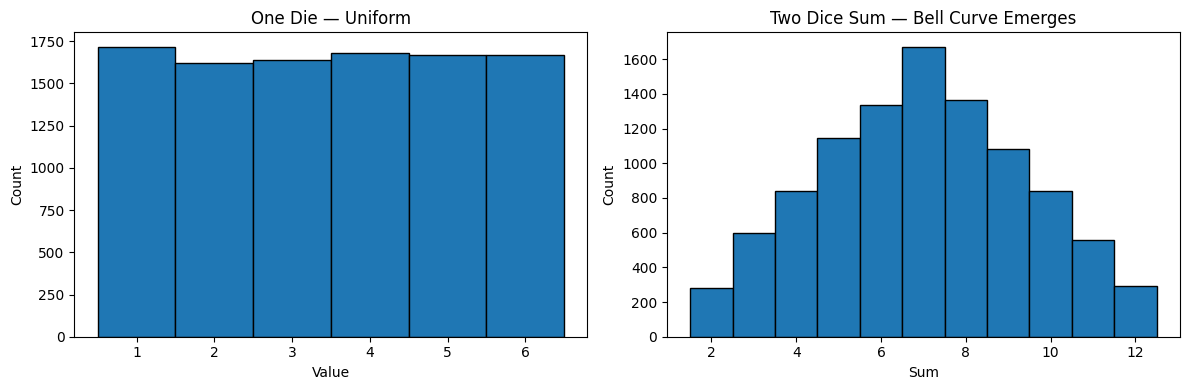

In [13]:
import random
import matplotlib.pyplot as plt

# UNIFORM: Roll one die 10,000 times
one_die = [random.randint(1, 6) for _ in range(10000)]

# Plot it
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(one_die, bins=range(1, 8), edgecolor="black", align="left")
plt.title("One Die — Uniform")
plt.xlabel("Value")
plt.ylabel("Count")

# Now roll TWO dice 10,000 times and plot the SUM
two_dice = [random.randint(1, 6) + random.randint(1, 6) for _ in range(10000)]

plt.subplot(1, 2, 2)
plt.hist(two_dice, bins=range(2, 14), edgecolor="black", align="left")
plt.title("Two Dice Sum — Bell Curve Emerges")
plt.xlabel("Sum")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

The Central Limit Theorem says:

If you take lots of random samples from something, and calculate the average each time, those averages start to form a bell curve.

Even if the original data itself is messy, skewed, or ugly.

In [14]:
import random
import math

# Generate "fake" BTC returns assuming a perfect bell curve
# mean 0.05% daily, std 3%
normal_returns = [random.gauss(0.0005, 0.03) for _ in range(2000)]

# Count events beyond 3 standard deviations (beyond 9%)
normal_extreme = sum(1 for r in normal_returns if abs(r) > 0.09)

print(f"Normal distribution: {normal_extreme} days beyond 3 sigma in 2000 days")
print(f"Expected by bell curve: {2000 * 0.003:.1f} days")  # 0.3% = 6 days

Normal distribution: 8 days beyond 3 sigma in 2000 days
Expected by bell curve: 6.0 days


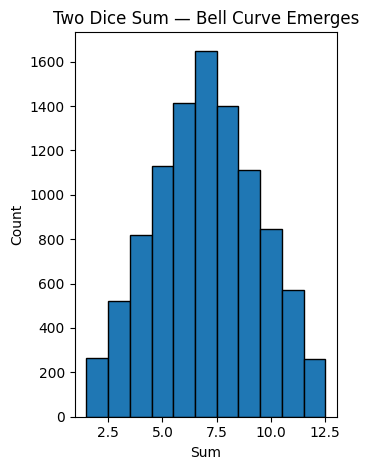

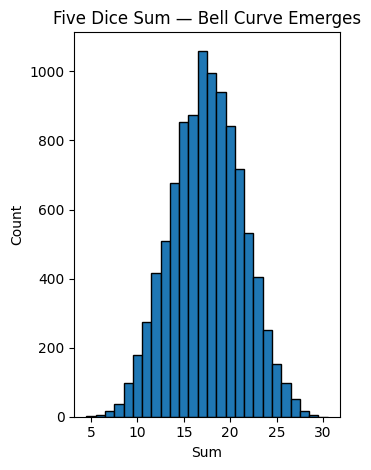

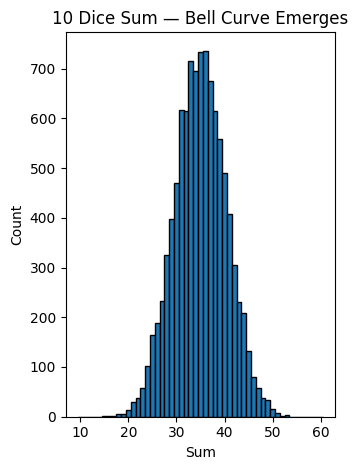

In [19]:
two_dice = [random.randint(1, 6) + random.randint(1, 6) for _ in range(10000)]

plt.subplot(1, 2, 2)
plt.hist(two_dice, bins=range(2, 14), edgecolor="black", align="left")
plt.title("Two Dice Sum — Bell Curve Emerges")
plt.xlabel("Sum")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

five_dice = [sum(random.randint(1, 6) for _ in range(5)) for _ in range(10000)]

plt.subplot(1, 2, 2)
plt.hist(five_dice, bins=range(5, 32), edgecolor="black", align="left")
plt.title("Five Dice Sum — Bell Curve Emerges")
plt.xlabel("Sum")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

ten_dice = [sum(random.randint(1, 6) for _ in range(10)) for _ in range(10000)]

plt.subplot(1, 2, 2)
plt.hist(ten_dice, bins=range(10, 62), edgecolor="black", align="left")
plt.title("10 Dice Sum — Bell Curve Emerges")
plt.xlabel("Sum")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [24]:
import random
import math

normal_returns = [random.gauss(0, 0.03) for _ in range(10000)]

sigma_three = sum(1 for r in normal_returns if abs(r) > 0.09)
sigma_two = sum(1 for r in normal_returns if abs(r) > 0.06)
sigma_one = sum(1 for r in normal_returns if abs(r) > 0.03)

print(f"Sigma_one: {sigma_one} ({sigma_one/10000:.2f}%)")
print(f"Sigma_two: {sigma_two} ({sigma_two/10000:.2f}%)")
print(f"Sigma_three: {sigma_three} ({sigma_three/10000:.2f}%)")

Sigma_one: 3167 (0.32%)
Sigma_two: 439 (0.04%)
Sigma_three: 34 (0.00%)


In [27]:
def expected_values(win_prob, win_amount, lose_amount, no_trades, daily_fees):
    lose_prob = 1 - win_prob
    return ((win_prob * win_amount) + (lose_prob * lose_amount)) * no_trades - daily_fees

trade_ev = expected_values(0.53, 15, -12, 50, 30)

print(f"Trade: ${trade_ev:.2f}")


Trade: $85.50
